In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('/content/telecom_churn_clean.csv')
display(df.head())

,Unnamed: 0,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls,churn
0,0,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,1,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,2,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,3,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,4,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


#Load Dataset
Dataseet is loaded correctly form the given path. First few rows show customer-related features like tenure, charges, and churns.Data appears structured and ready for initial inspection.

### Data Cleaning and Preprocessing

In [4]:
# Display basic information about the DataFrame
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              3333 non-null   int64  
 1   account_length          3333 non-null   int64  
 2   area_code               3333 non-null   int64  
 3   international_plan      3333 non-null   int64  
 4   voice_mail_plan         3333 non-null   int64  
 5   number_vmail_messages   3333 non-null   int64  
 6   total_day_minutes       3333 non-null   float64
 7   total_day_calls         3333 non-null   int64  
 8   total_day_charge        3333 non-null   float64
 9   total_eve_minutes       3333 non-null   float64
 10  total_eve_calls         3333 non-null   int64  
 11  total_eve_charge        3333 non-null   float64
 12  total_night_minutes     3333 non-null   float64
 13  total_night_calls       3333 non-null   int64  
 14  total_night_charge      3333 non-null   

None

#dataset info
data types of columns are displayed clearly. Numerical and categorical variables are identified. Helps in deciding further preprocessing steps.

In [5]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")



Number of duplicate rows: 0


In [7]:
# if there are duplicates, drop them
if duplicate_rows > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")
    print(f"New DataFrame shape: {df.shape}")

In [8]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

if missing_values.empty:
    print("No missing values found in the dataset.")
else:
    print("Missing values per column:")
    display(missing_values)

No missing values found in the dataset.


#checking missing values
Missing values (if any) are clearly visible column-wise. Clean dataset should ideally show zero or veery few missing values. Helps decide whether to drop or impute missing data.

### Outlier Identification

Outliers are data points that significantly deviate from other observations in a dataset. They can be due to measurement errors, data entry mistakes, or genuinely rare events. Identifying and handling outliers is important because they can disproportionately influence statistical analyses and machine learning models.

One common method to detect outliers is the **Interquartile Range (IQR) Method**:
1.  **Calculate the first quartile (Q1)**: The 25th percentile of the data.
2.  **Calculate the third quartile (Q3)**: The 75th percentile of the data.
3.  **Calculate the IQR**: IQR = Q3 - Q1.
4.  **Define outlier bounds**: Any data point below `Q1 - 1.5 * IQR` or above `Q3 + 1.5 * IQR` is considered an outlier.

In [10]:
# Identify outliers using the IQR method for 'total_day_minutes'

Q1 = df['total_day_minutes'].quantile(0.25)
Q3 = df['total_day_minutes'].quantile(0.75)
IQR = Q3 - Q1
print(Q1)
print(Q3)
print(IQR)

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['total_day_minutes'] < lower_bound) | (df['total_day_minutes'] > upper_bound)]

print(f"Number of outliers in 'total_day_minutes': {len(outliers)}")
if not outliers.empty:
    print("\nFirst 5 outliers (if any):")
    display(outliers.head())

143.7
216.4
72.70000000000002
Number of outliers in 'total_day_minutes': 25

First 5 outliers (if any):


,Unnamed: 0,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls,churn
15,15,161,415,0,0,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,1
156,156,83,415,0,0,0,337.4,120,57.36,227.4,116,19.33,153.9,114,6.93,15.8,7,4.27,0,1
197,197,208,510,0,0,0,326.5,67,55.51,176.3,113,14.99,181.7,102,8.18,10.7,6,2.89,2,1
365,365,154,415,0,0,0,350.8,75,59.64,216.5,94,18.40,253.9,100,11.43,10.1,9,2.73,1,1
605,605,112,415,0,0,0,335.5,77,57.04,212.5,109,18.06,265.0,132,11.93,12.7,8,3.43,2,1


#outlier identification
Some extreme values are present as outlierrs. Most data opoints lie within a normal range. Outliers may influence statistical results and models.

You can apply similar logic to other numerical columns if needed, or visualize these outliers to better understand their distribution.

### Univariate Analysis

Univariate analysis involves examining a single variable at a time to understand its characteristics, such as its distribution, central tendency, and dispersion. Common techniques include:

*   **Descriptive Statistics**: Mean, median, mode, standard deviation, variance, quartiles.
*   **Frequency Distributions**: For categorical variables, showing counts or percentages of each category.
*   **Visualizations**: Histograms, box plots, density plots (for numerical variables), and bar charts (for categorical variables).

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Descriptive statistics for 'total_day_minutes'
print("Descriptive statistics for 'total_day_minutes':\n")
display(df['total_day_minutes'].describe())

Descriptive statistics for 'total_day_minutes':



,total_day_minutes
count,3333.000000
mean,179.775098
std,54.467389
min,0.000000
25%,143.700000
50%,179.400000
75%,216.400000
max,350.800000


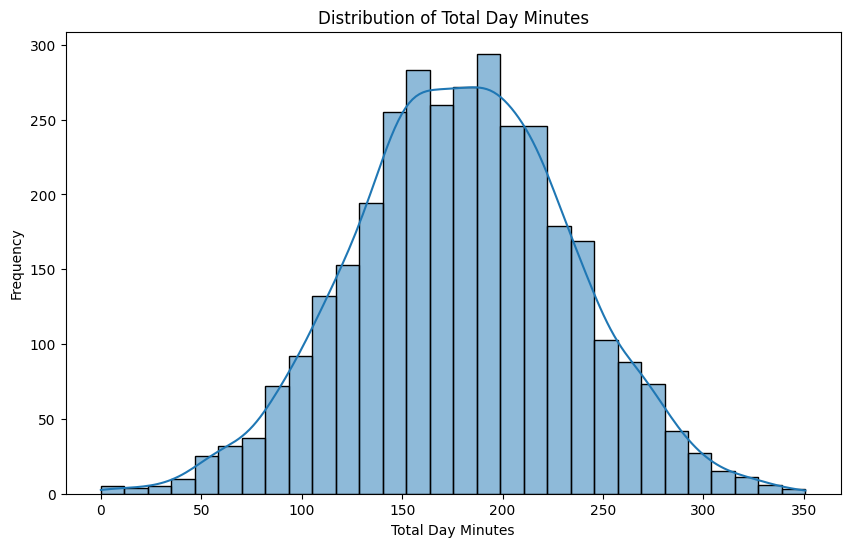

In [12]:
# Histogram for 'total_day_minutes'
plt.figure(figsize=(10, 6))
sns.histplot(df['total_day_minutes'], kde=True, bins=30)
plt.title('Distribution of Total Day Minutes')
plt.xlabel('Total Day Minutes')
plt.ylabel('Frequency')
plt.show()

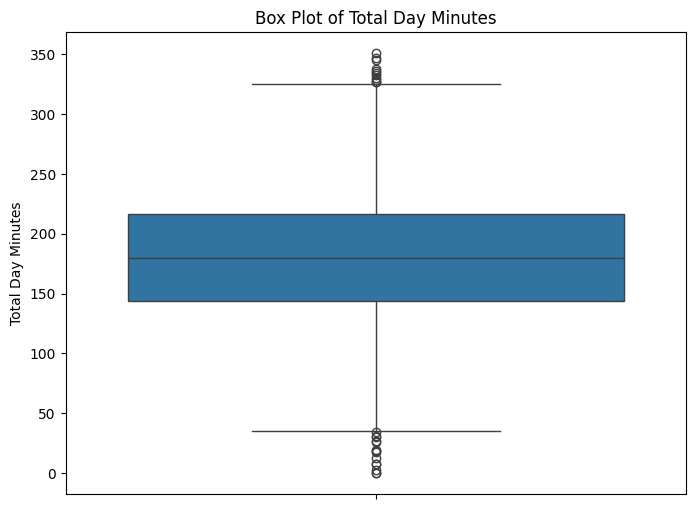

In [13]:
# Box plot for 'total_day_minutes'
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['total_day_minutes'])
plt.title('Box Plot of Total Day Minutes')
plt.ylabel('Total Day Minutes')
plt.show()

#univariate analysis
Most customers have low tenure values. Indicates many users are new or recently joined. Suggests higher churn risk in early stages.

### Bivariate Analysis and EDA

**Bivariate Analysis** is a statistical method that examines the relationship between two variables simultaneously. The goal is to determine if there's an empirical relationship between them, how strong that relationship is, and in what direction.

Common techniques include:
*   **Scatter Plots**: For two numerical variables, to show patterns, clusters, or correlations.
*   **Box Plots or Violin Plots**: For one numerical and one categorical variable, to compare the distribution of the numerical variable across different categories.
*   **Grouped Bar Charts**: For two categorical variables, to show the frequency distribution of one category within each group of another.
*   **Correlation Matrices/Heatmaps**: To quantify the linear relationship between multiple pairs of numerical variables.

**Exploratory Data Analysis (EDA)** is an approach to analyzing data sets to summarize their main characteristics, often with visual methods. A statistical model can be used or not, but primarily EDA is for seeing what the data can tell us beyond the formal modeling or hypothesis testing task. EDA aims to:
1.  **Understand the data**: Get a feel for its structure, variables, and overall content.
2.  **Discover patterns**: Identify relationships between variables.
3.  **Detect anomalies**: Find outliers or unusual observations.
4.  **Formulate hypotheses**: Generate ideas for further investigation.
5.  **Check assumptions**: Verify assumptions required for statistical modeling.

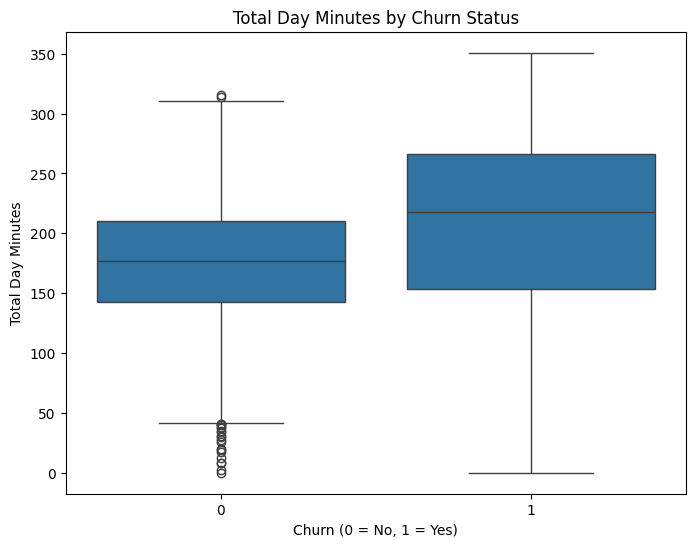

In [14]:
# Bivariate analysis: Box plot of 'total_day_minutes' by 'churn'
plt.figure(figsize=(8, 6))
sns.boxplot(x='churn', y='total_day_minutes', data=df)
plt.title('Total Day Minutes by Churn Status')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Total Day Minutes')
plt.show()

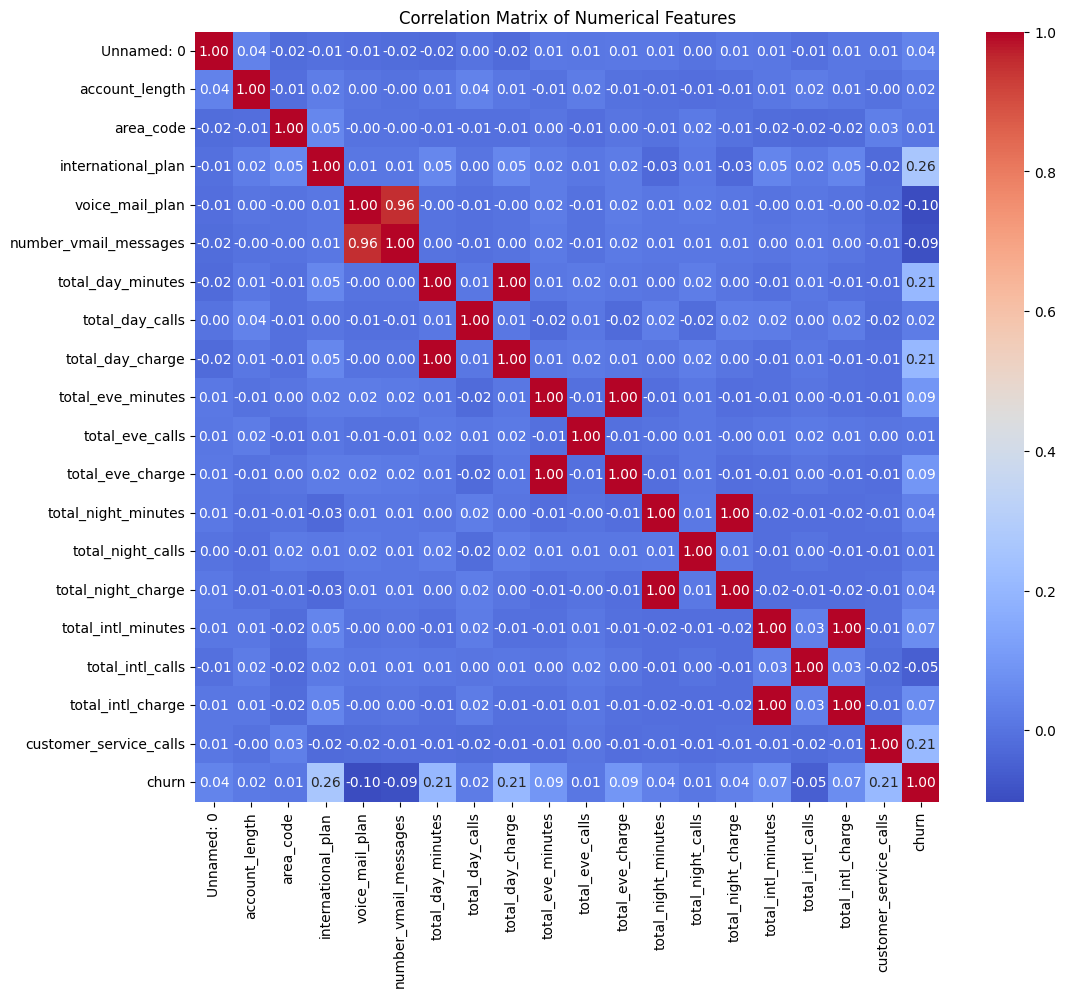

In [15]:
# Correlation Heatmap for numerical features

# Select only numerical columns for correlation calculation
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

#### Scatter Plot: `total_day_minutes` vs `total_day_charge`

This plot helps visualize the relationship between two numerical variables. Given that `total_day_charge` is likely derived from `total_day_minutes`, we expect a strong positive linear relationship.

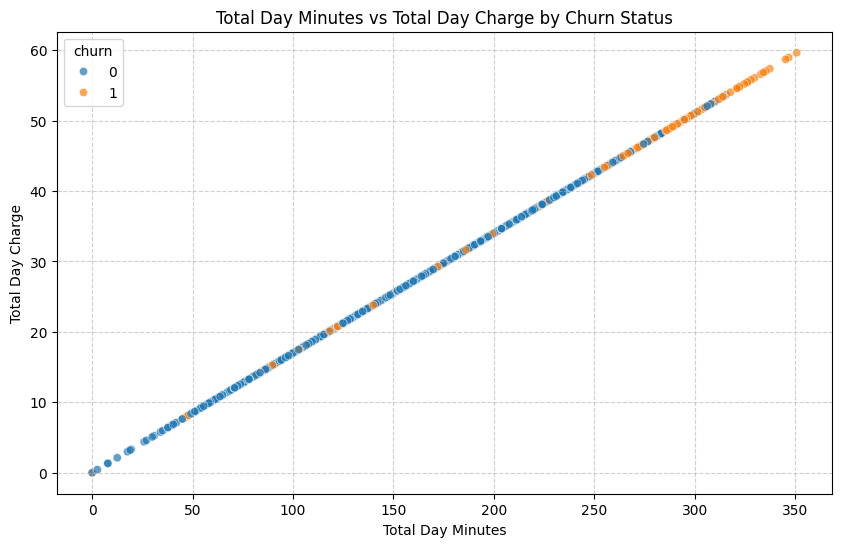

In [16]:
# Scatter plot for total_day_minutes vs total_day_charge
plt.figure(figsize=(10, 6))
sns.scatterplot(x='total_day_minutes', y='total_day_charge', hue='churn', data=df, alpha=0.7)
plt.title('Total Day Minutes vs Total Day Charge by Churn Status')
plt.xlabel('Total Day Minutes')
plt.ylabel('Total Day Charge')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### Violin Plot: `total_eve_minutes` by `international_plan`

A violin plot is similar to a box plot but also shows the probability density of the data at different values, which can be useful for comparing distributions across different categories.

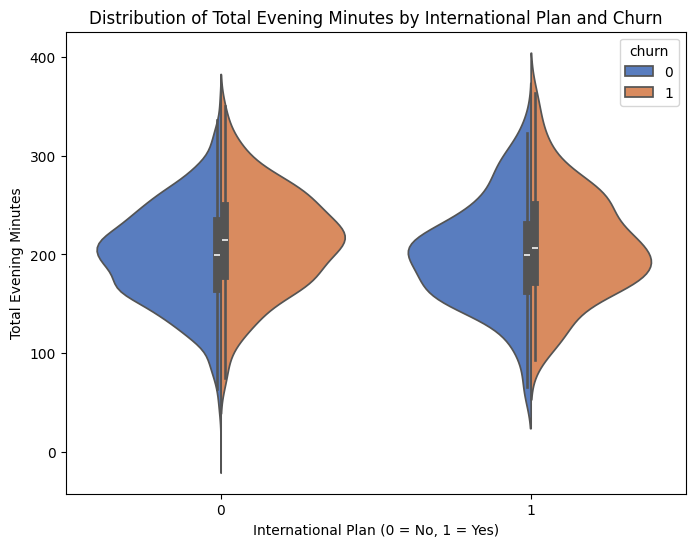

In [17]:
# Violin plot of total_eve_minutes by international_plan
plt.figure(figsize=(8, 6))
sns.violinplot(x='international_plan', y='total_eve_minutes', hue='churn', data=df, palette='muted', split=True)
plt.title('Distribution of Total Evening Minutes by International Plan and Churn')
plt.xlabel('International Plan (0 = No, 1 = Yes)')
plt.ylabel('Total Evening Minutes')
plt.show()

#### Grouped Bar Chart: Churn Rate by `international_plan` and `voice_mail_plan`

This chart helps compare a numerical value (churn rate) across two categorical variables, showing how different combinations of categories impact the churn.

<Figure size 1000x700 with 0 Axes>

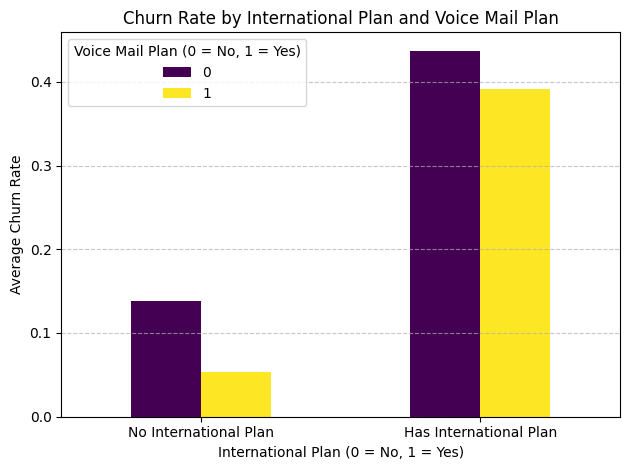

In [18]:
# Grouped bar chart for churn rate by international_plan and voice_mail_plan
churn_rates = df.groupby(['international_plan', 'voice_mail_plan'])['churn'].mean().unstack()

plt.figure(figsize=(10, 7))
churn_rates.plot(kind='bar', rot=0, cmap='viridis')
plt.title('Churn Rate by International Plan and Voice Mail Plan')
plt.xlabel('International Plan (0 = No, 1 = Yes)')
plt.ylabel('Average Churn Rate')
plt.xticks(ticks=[0, 1], labels=['No International Plan', 'Has International Plan'])
plt.legend(title='Voice Mail Plan (0 = No, 1 = Yes)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()